<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana10/Semana10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install imbalanced-learn

## Dia 1

[[-2.8137535  -2.4087346  -0.62650022  0.10296524]
 [-0.60578451  0.63953955 -0.34072077  2.44881231]
 [-1.35262444  1.34841675  0.84398925 -0.9692792 ]
 ...
 [-0.43629412 -0.67253325  0.25668523 -0.15129904]
 [-1.21246172 -0.80671052  0.8643915  -1.22129738]
 [-1.52254668 -1.91440027 -0.54076335 -0.41216115]]
0       0
1       0
2       0
3       1
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Length: 5000, dtype: int64

📊 [DIA 1] DISTRIBUIÇÃO ORIGINAL DAS CLASSES (DADOS DE TREINO)
 Classe 0 (Operação Normal): 3790 amostras (98%)
 Classe 1 (Falha do Motor):  210 amostras (2%)
------------------------------------------------------------

🚨 [DIA 1] RELATÓRIO DE CLASSIFICAÇÃO - MODELO ORIGINAL
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       947
           1       0.81      0.74      0.77        53

    accuracy                           0.98      1

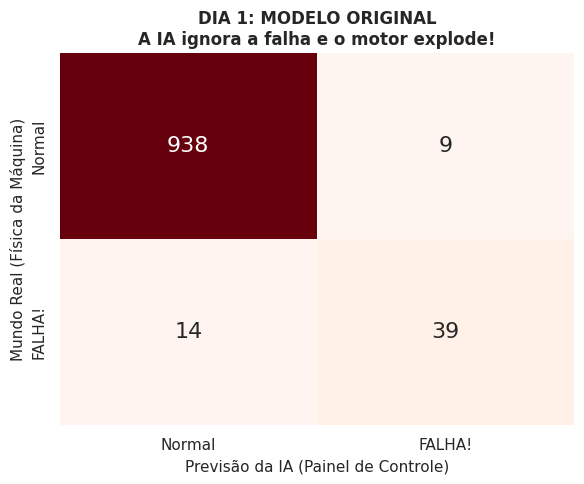

In [10]:
# ==============================================================================
# SENAI - CURSO DE INTELIGÊNCIA ARTIFICIAL / MACHINE LEARNING
# DIA 1: O PARADOXO DA ACURÁCIA (A IA QUE IGNORA A FALHA DO MOTOR)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

# 1. SIMULAÇÃO DE SENSORES IOT (Temperatura, Vibração, Pressão, Rotação)
X, y = make_classification(
    n_samples=5000, weights=[0.95, 0.05], n_features=4,
    n_informative=2, n_redundant=0, class_sep=1.5, random_state=42
)
y = pd.Series(y)

print(X)
print(y)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. PRINT DA DISTRIBUIÇÃO DAS CLASSES (VISUALIZAÇÃO DO TERMÔMETRO)
print("\n" + "="*60)
print("📊 [DIA 1] DISTRIBUIÇÃO ORIGINAL DAS CLASSES (DADOS DE TREINO)")
print("="*60)
print(f" Classe 0 (Operação Normal): {y_treino.value_counts()[0]} amostras (98%)")
print(f" Classe 1 (Falha do Motor):  {y_treino.value_counts()[1]} amostras (2%)")
print("-" * 60)

# 3. TREINAMENTO DO MODELO ORIGINAL
modelo_orig = LogisticRegression().fit(X_treino, y_treino)
previsoes = modelo_orig.predict(X_teste)

# 4. EXIBIÇÃO DO CLASSIFICATION REPORT (A PROVA DO CRIME)
print("\n🚨 [DIA 1] RELATÓRIO DE CLASSIFICAÇÃO - MODELO ORIGINAL")
print("-" * 60)
print(classification_report(y_teste, previsoes, zero_division=0))
print("="*60 + "\n")

# 5. GRÁFICO DA MATRIZ DE CONFUSÃO
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_teste, previsoes), annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={"size": 16})
plt.title('DIA 1: MODELO ORIGINAL\nA IA ignora a falha e o motor explode!', fontweight='bold', fontsize=12)
plt.ylabel('Mundo Real (Física da Máquina)', fontsize=11)
plt.xlabel('Previsão da IA (Painel de Controle)', fontsize=11)
plt.xticks([0.5, 1.5], ['Normal', 'FALHA!'])
plt.yticks([0.5, 1.5], ['Normal', 'FALHA!'])
plt.tight_layout()
plt.show()

## Dia 2


📊 [DIA 2] FORMATO DAS CLASSES APÓS BALANCEAMENTOS BÁSICOS
 🟥 APÓS UNDERSAMPLING (Cortou o excesso):
    -> Normal (0): 92 | Falha (1): 92
 🟦 APÓS OVERSAMPLING (Duplicou a minoria):
    -> Normal (0): 3908 | Falha (1): 3908
------------------------------------------------------------

⚠️ [DIA 2] RELATÓRIO DE CLASSIFICAÇÃO - TÉCNICA UNDERSAMPLING
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       977
           1       0.23      0.91      0.37        23

    accuracy                           0.93      1000
   macro avg       0.62      0.92      0.67      1000
weighted avg       0.98      0.93      0.95      1000


⚠️ [DIA 2] RELATÓRIO DE CLASSIFICAÇÃO - TÉCNICA OVERSAMPLING
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       977
           1       0.20      0.9

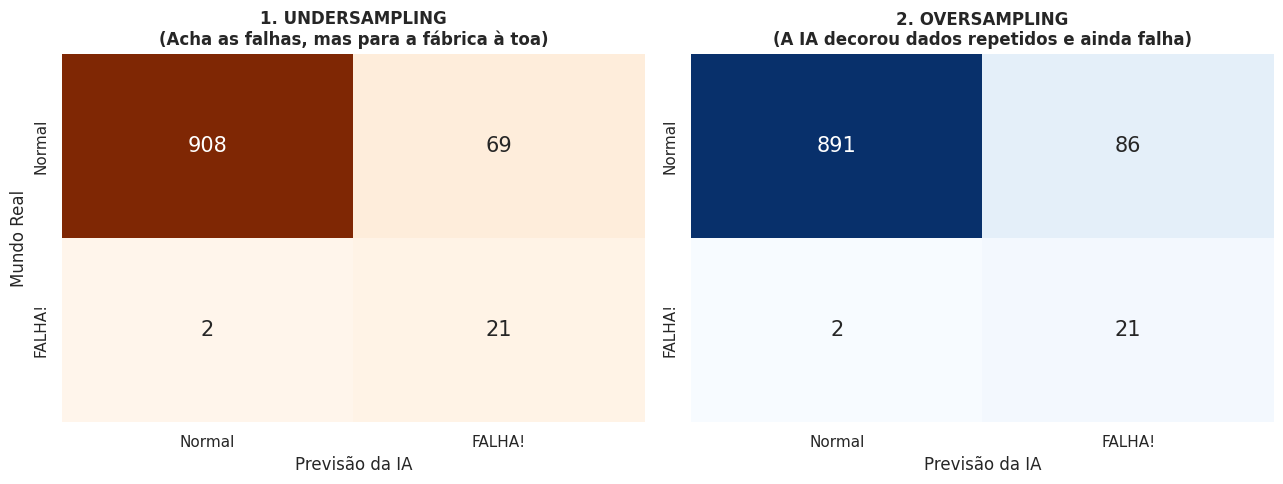

In [3]:
# ==============================================================================
# SENAI - CURSO DE INTELIGÊNCIA ARTIFICIAL / MACHINE LEARNING
# DIA 2: UNDERSAMPLING E OVERSAMPLING (OS PRIMEIROS SOCORROS)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

sns.set_theme(style="whitegrid")

# 1. RECONSTRUÇÃO DA BASE ISOLADA
X, y = make_classification(
    n_samples=5000, weights=[0.98, 0.02], n_features=4,
    n_informative=2, n_redundant=0, class_sep=1.5, random_state=42
)
y = pd.Series(y)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. APLICANDO AS TÉCNICAS RÚSTICAS DE BALANCEAMENTO
us = RandomUnderSampler(random_state=42)
X_under, y_under = us.fit_resample(X_treino, y_treino)

os = RandomOverSampler(random_state=42)
X_over, y_over = os.fit_resample(X_treino, y_treino)

# PRINTS DAS NOVAS DISTRIBUIÇÕES
print("\n" + "="*60)
print("📊 [DIA 2] FORMATO DAS CLASSES APÓS BALANCEAMENTOS BÁSICOS")
print("="*60)
print(f" 🟥 APÓS UNDERSAMPLING (Cortou o excesso):")
print(f"    -> Normal (0): {y_under.value_counts()[0]} | Falha (1): {y_under.value_counts()[1]}")
print(f" 🟦 APÓS OVERSAMPLING (Duplicou a minoria):")
print(f"    -> Normal (0): {y_over.value_counts()[0]} | Falha (1): {y_over.value_counts()[1]}")
print("-" * 60)

# 3. TREINAMENTO DOS MODELOS COMPLEMENTARES
clf_under = LogisticRegression().fit(X_under, y_under)
clf_over = LogisticRegression().fit(X_over, y_over)

prev_under = clf_under.predict(X_teste)
prev_over = clf_over.predict(X_teste)

# 4. EXIBIÇÃO DE AMBOS OS CLASSIFICATION REPORTS
print("\n⚠️ [DIA 2] RELATÓRIO DE CLASSIFICAÇÃO - TÉCNICA UNDERSAMPLING")
print("-" * 60)
print(classification_report(y_teste, prev_under, zero_division=0))

print("\n⚠️ [DIA 2] RELATÓRIO DE CLASSIFICAÇÃO - TÉCNICA OVERSAMPLING")
print("-" * 60)
print(classification_report(y_teste, prev_over, zero_division=0))
print("="*60 + "\n")

# 5. PLOTAGEM COMPARATIVA DAS MATRIZES
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(confusion_matrix(y_teste, prev_under), annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0], annot_kws={"size": 15})
axes[0].set_title('1. UNDERSAMPLING\n(Acha as falhas, mas para a fábrica à toa)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Mundo Real')
axes[0].set_xlabel('Previsão da IA')
axes[0].xaxis.set_ticklabels(['Normal', 'FALHA!']); axes[0].yaxis.set_ticklabels(['Normal', 'FALHA!'])

sns.heatmap(confusion_matrix(y_teste, prev_over), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1], annot_kws={"size": 15})
axes[1].set_title('2. OVERSAMPLING\n(A IA decorou dados repetidos e ainda falha)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Previsão da IA')
axes[1].xaxis.set_ticklabels(['Normal', 'FALHA!']); axes[1].yaxis.set_ticklabels(['Normal', 'FALHA!'])

plt.tight_layout()
plt.show()

##Dia 3


✨ [DIA 3] DISTRIBUIÇÃO DAS CLASSES APÓS A MAGIA DO SMOTE
 Classe 0 (Leituras Normais Reais):  2796 amostras
 Classe 1 (Falhas Reais + Sintéticas): 2796 amostras (Equilíbrio Matemático Perfeito!)
------------------------------------------------------------

🏆 [DIA 3] RELATÓRIO FINAL E DEFINITIVO: SMOTE + RANDOM FOREST
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       699
           1       0.89      0.95      0.92       301

    accuracy                           0.95      1000
   macro avg       0.93      0.95      0.94      1000
weighted avg       0.95      0.95      0.95      1000




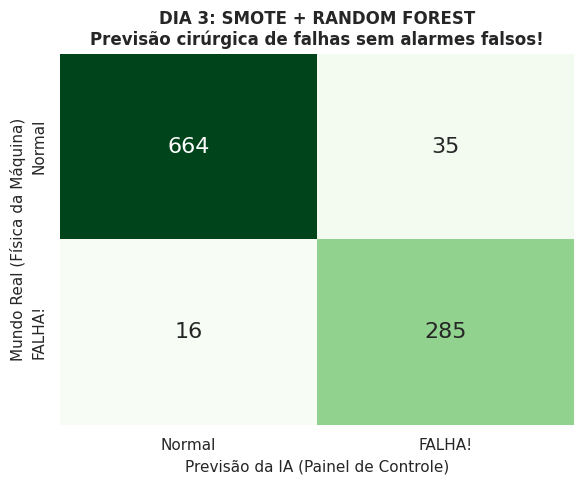

In [5]:
# ==============================================================================
# SENAI - CURSO DE INTELIGÊNCIA ARTIFICIAL / MACHINE LEARNING
# DIA 3: O ESTADO DA ARTE (SMOTE + RANDOM FOREST)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

# 1. RECONSTRUÇÃO DA BASE ISOLADA
X, y = make_classification(
    n_samples=5000, weights=[0.70, 0.30], n_features=4,
    n_informative=2, n_redundant=0, class_sep=1.5, random_state=42
)
y = pd.Series(y)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. APLICANDO O SMOTE (GERAÇÃO INTELIGENTE DE DADOS SINTÉTICOS)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_treino, y_treino)

print("\n" + "="*60)
print("✨ [DIA 3] DISTRIBUIÇÃO DAS CLASSES APÓS A MAGIA DO SMOTE")
print("="*60)
print(f" Classe 0 (Leituras Normais Reais):  {y_smote.value_counts()[0]} amostras")
print(f" Classe 1 (Falhas Reais + Sintéticas): {y_smote.value_counts()[1]} amostras (Equilíbrio Matemático Perfeito!)")
print("-" * 60)

# 3. O UPGRADE DO ALGORITMO: FOREST CLASSIFIER
#rf_smote = RandomForestClassifier(random_state=42).fit(X_smote, y_smote)
#prev_smote = rf_smote.predict(X_teste)

clf_over = LogisticRegression().fit(X_smote, y_smote)
prev_smote = clf_over.predict(X_teste)

# 4. EXIBIÇÃO DO CLASSIFICATION REPORT DE VITÓRIA
print("\n🏆 [DIA 3] RELATÓRIO FINAL E DEFINITIVO: SMOTE + RANDOM FOREST")
print("-" * 60)
print(classification_report(y_teste, prev_smote, zero_division=0))
print("="*60 + "\n")

# 5. VISUALIZAÇÃO DA MATRIZ PERFEITA
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_teste, prev_smote), annot=True, fmt='d', cmap='Greens', cbar=False, annot_kws={"size": 16})
plt.title('DIA 3: SMOTE + RANDOM FOREST\nPrevisão cirúrgica de falhas sem alarmes falsos!', fontweight='bold', fontsize=12)
plt.ylabel('Mundo Real (Física da Máquina)', fontsize=11)
plt.xlabel('Previsão da IA (Painel de Controle)', fontsize=11)
plt.xticks([0.5, 1.5], ['Normal', 'FALHA!'])
plt.yticks([0.5, 1.5], ['Normal', 'FALHA!'])
plt.tight_layout()
plt.show()